# Same-start runs

Every clip here begins from one of **five saved spawn layouts**. A run with random movement has a
partner with none that started from the identical arrangement of agents, so a difference between
the two traces is the parameter and not the spawn.

The report goes: what is in the folder, the five starts, hull area over time, wall contact, the
rate of change, and finally each randomised run measured against its own no-randomness partner.

Everything is imported from `same_start.py` — no measure is reimplemented here, and hull area and
wall contacts are both read straight from the recordings, where Unity computed them at capture
time.

In [38]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import same_start as sst
import steady_state as ss

RECORDINGS = Path("../../Assets/SimulationRecordings/Combinations/20260825_014231")

runs = sst.load_folder(RECORDINGS)
inv = sst.inventory(runs)

print(f"{len(runs)} clips from {RECORDINGS.name}\n")
print(sst.describe(inv))

# pandas .style needs a recent jinja2. Probe the capability rather than the import: an old
# jinja2 imports fine but pandas still refuses it, so `import jinja2` is not the right test.
# The tables are the point of these cells, the colouring is not, so degrade instead of failing.
try:
    pd.DataFrame({"x": [0]}).style.background_gradient()
    _STYLED = True
except Exception as exc:
    _STYLED = False
    print(f"unstyled tables ({exc}). Fix with:  "
          f"conda env update -n PythonAnalysis -f ../environment.yml")


def show(df, caption=None, cmap="Blues", subset=None, vmin=None, vmax=None):
    """Display a frame, colour-graded when pandas styling is available."""
    if not _STYLED:
        if caption:
            print(caption)
        display(df)
        return
    styled = df.style.background_gradient(cmap=cmap, axis=None, subset=subset,
                                          vmin=vmin, vmax=vmax)
    display(styled.set_caption(caption) if caption else styled)

390 clips from 20260825_014231

random movement : 0, 40, 80
max speed       : 1.5, 4
perception radii: 13 levels, 0.15 to 3.5
                  0.15, 0.45, 0.9, 1.15, 1.5, 1.8, 2, 2.25, 2.5, 2.75, 3, 3.25, 3.5
spawn layouts   : 5  (all shared by every condition)

   motion         random  maxSpeed  clips  layouts  radii  R range
   Dispersion          0       1.5     65        5     13  0.15-3.5
   Dispersion          0       4.0     65        5     13  0.15-3.5
   Dispersion         40       1.5     65        5     13  0.15-3.5
   Dispersion         40       4.0     65        5     13  0.15-3.5
   Dispersion         80       1.5     65        5     13  0.15-3.5
   Dispersion         80       4.0     65        5     13  0.15-3.5
unstyled tables (The '.style' accessor requires jinja2). Fix with:  conda env update -n PythonAnalysis -f ../environment.yml


In [39]:
design = pd.DataFrame(inv["rows"])
display(design)

print("randoms   :", inv["randoms"])
print("maxSpeeds :", inv["speeds"])
print("radii     :", inv["radii"])
print("layouts   :", [sst._short(x) for x in inv["layouts"]])

,motion,random,maxSpeed,clips,radii,layouts,R_min,R_max,batches
0,Dispersion,0,1.5,65,13,5,0.15,3.5,1
1,Dispersion,0,4.0,65,13,5,0.15,3.5,1
2,Dispersion,40,1.5,65,13,5,0.15,3.5,1
3,Dispersion,40,4.0,65,13,5,0.15,3.5,1
4,Dispersion,80,1.5,65,13,5,0.15,3.5,1
5,Dispersion,80,4.0,65,13,5,0.15,3.5,1


randoms   : [0, 40, 80]
maxSpeeds : [1.5, 4.0]
radii     : [0.15, 0.45, 0.9, 1.15, 1.5, 1.8, 2.0, 2.25, 2.5, 2.75, 3.0, 3.25, 3.5]
layouts   : ['00', '01', '02', '03', '04']


### Coverage holes

A missing cell here is not a small gap: it means a randomised run has no reference at that radius,
so it cannot be compared within layout and it silently vanishes from any paired analysis.

In [40]:
grid = (pd.DataFrame([{"maxSpeed": r["speed"], "random": r["random"], "R": r["R"]}
                      for r in runs])
         .pivot_table(index="R", columns=["maxSpeed", "random"], aggfunc=len, values="R")
         .fillna(0).astype(int))

show(grid, "clips per perception radius (0 = not recorded)")

for speed in inv["speeds"]:
    ref = {r["R"] for r in sst.select(runs, speed=speed, random=0)}
    rnd = {r["R"] for r in runs if r["speed"] == speed and r["random"] > 0}
    if ref - rnd:
        print(f"maxSpeed {speed:g}: reference only, no randomised partner at "
              f"{sorted(ref - rnd)}")
    if rnd - ref:
        print(f"maxSpeed {speed:g}: randomised only, no reference at {sorted(rnd - ref)}")

clips per perception radius (0 = not recorded)


maxSpeed 1.5       4.0      
random    0  40 80  0  40 80
R                           
0.15       5  5  5   5  5  5
0.45       5  5  5   5  5  5
0.90       5  5  5   5  5  5
1.15       5  5  5   5  5  5
1.50       5  5  5   5  5  5
1.80       5  5  5   5  5  5
2.00       5  5  5   5  5  5
2.25       5  5  5   5  5  5
2.50       5  5  5   5  5  5
2.75       5  5  5   5  5  5
3.00       5  5  5   5  5  5
3.25       5  5  5   5  5  5
3.50       5  5  5   5  5  5

## 2. The five starting positions

Crosses are the layout as saved at spawn. Rings are the first *recorded* frame of one run per
condition on that layout.

They do not quite coincide for the randomised conditions, and that is expected rather than a
pairing failure: capture begins a few frames after motion is enabled, and random movement acts
immediately. The drift is quantified underneath — about one agent diameter, with no effect on the
frame-0 hull area.

In [41]:
layouts = sst.load_layouts(runs, RECORDINGS)
fig = sst.layout_figure(runs, layouts)
plt.show()

ValueError: Number of columns must be a positive integer, not 0

<Figure size 180x360 with 0 Axes>

In [ ]:
rows = []
for run in runs:
    saved = layouts.get(run["layout"])
    if saved is None:
        continue
    first = sst.frame_zero(run)
    if first is None or len(first) != len(saved):
        continue
    d = np.hypot(*(first - saved).T)
    rows.append({"random": run["random"], "maxSpeed": run["speed"],
                 "mean_drift_u": d.mean(), "max_drift_u": d.max(),
                 "hull_at_frame0": run["areas"][0]})

drift = pd.DataFrame(rows).groupby(["random", "maxSpeed"]).mean().round(3)
display(drift)
print("spawn layouts are identical by construction; the drift is capture latency, not spawn "
      "variation.\nFrame-0 hull area is unchanged across conditions, so it does not bias the "
      "comparison.")

mean_drift_u  max_drift_u  hull_at_frame0
random maxSpeed                                           
0      1.5              0.018        0.038          25.271
       4.0              0.018        0.038          25.271
40     1.5              0.121        0.162          25.155
       4.0              0.139        0.241          25.316
80     1.5              0.159        0.184          25.027
       4.0              0.265        0.392          25.250

spawn layouts are identical by construction; the drift is capture latency, not spawn variation.
Frame-0 hull area is unchanged across conditions, so it does not bias the comparison.


## 3. Hull area over time, per layout

One panel per starting layout, colour is perception radius, line style is the random level. The
smooth curves that rise and flatten early are the no-randomness references. The rough curves that
keep climbing are the randomised runs — at this speed most never settle inside the 60 s window.

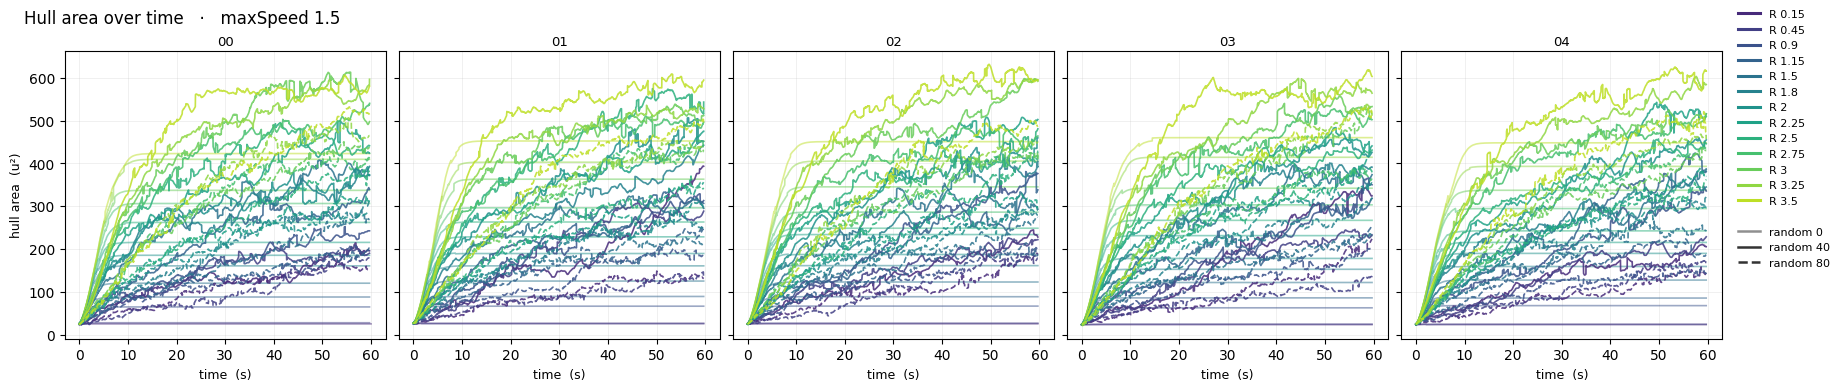

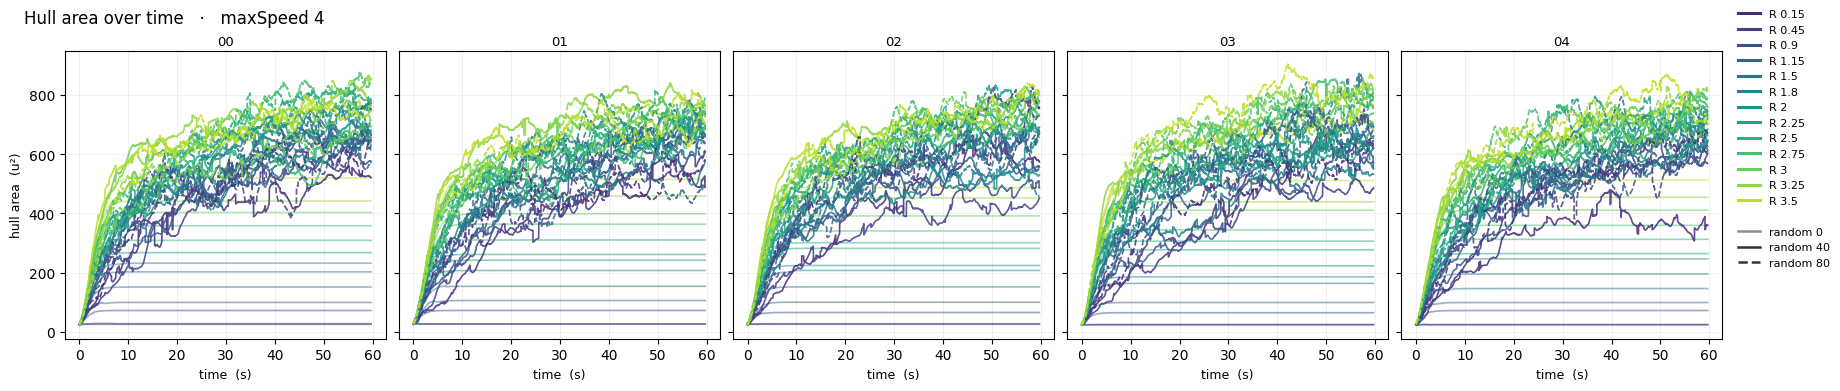

In [ ]:
for speed in inv["speeds"]:
    sst.hull_figure(runs, speed)
    plt.show()

Normalising each trace by its own frame-0 area puts every radius on one scale, which makes the
*shape* comparable when the absolute areas differ by an order of magnitude.

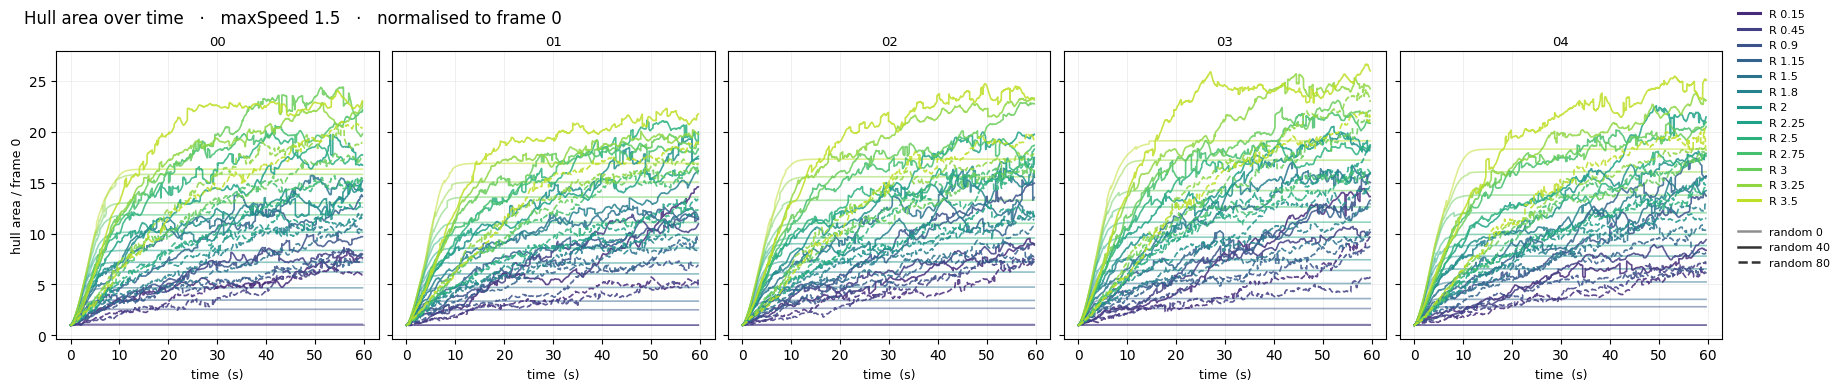

In [ ]:
sst.hull_figure(runs, inv["speeds"][0], normalise=True)
plt.show()

## 4. Wall contact

Cumulative share of the swarm that has touched a wall at least once. This is the confound to watch:
once agents are riding the boundary, the hull is reporting the arena rather than the swarm.

Contacts are recorded in Unity against the walls that were **active for that run**, so a motion
type with walls disabled is already accounted for. Note it is a geometric test rather than a
physics event — agents are moved by writing `transform.position`, so collision callbacks never
see a sweep.

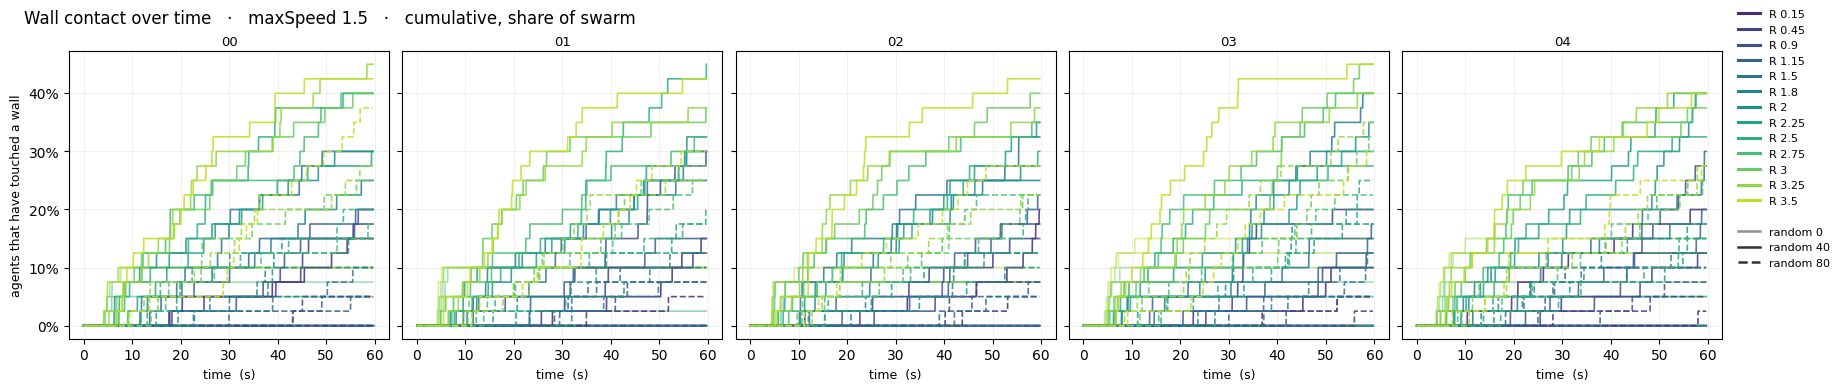

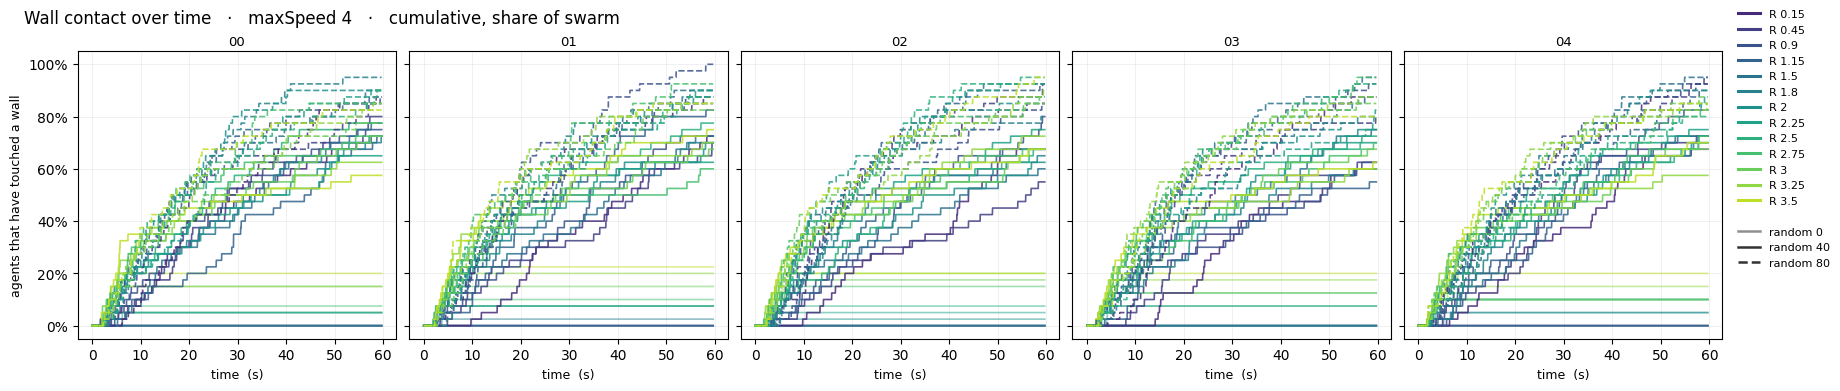

In [ ]:
for speed in inv["speeds"]:
    sst.contacts_figure(runs, speed)
    plt.show()

In [ ]:
budget = 0.20
rows = []
for run in runs:
    n = max(int(run["header"].get("agentCount", 1)), 1)
    rows.append({"maxSpeed": run["speed"], "random": run["random"], "R": run["R"],
                 "touched_by_end": run["unique"][-1] / n})

walls = (pd.DataFrame(rows).groupby(["maxSpeed", "random", "R"])["touched_by_end"]
           .mean().unstack("R").round(2))
show(walls, f"share of swarm that touched a wall by the end of the clip (budget {budget:.0%})",
     cmap="Reds", vmin=0, vmax=1)

share of swarm that touched a wall by the end of the clip (budget 20%)


R                0.15  0.45  0.90  1.15  1.50  1.80  2.00  2.25  2.50  2.75  \
maxSpeed random                                                               
1.5      0       0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.02  0.05  0.08   
         40      0.16  0.16  0.22  0.19  0.26  0.28  0.33  0.33  0.35  0.38   
         80      0.04  0.04  0.05  0.07  0.09  0.11  0.14  0.16  0.20  0.22   
4.0      0       0.00  0.00  0.00  0.00  0.00  0.02  0.04  0.07  0.08  0.11   
         40      0.68  0.68  0.74  0.70  0.72  0.68  0.70  0.70  0.73  0.68   
         80      0.88  0.88  0.92  0.88  0.92  0.88  0.87  0.88  0.89  0.88   

R                3.00  3.25  3.50  
maxSpeed random                    
1.5      0       0.10  0.11  0.12  
         40      0.40  0.40  0.42  
         80      0.26  0.28  0.30  
4.0      0       0.14  0.18  0.20  
         40      0.68  0.64  0.66  
         80      0.84  0.86  0.86

## 5. Rate of change, d(hull)/dt

The same series differentiated over a rolling window. Hull area tells you *where* the swarm got;
its slope tells you *whether it is still going*, which is the only way to distinguish a genuine
steady state from a run that simply ran out of time.

Read it as: the references pulse and return to zero — that return **is** the plateau. The
randomised runs sit at a positive value for the whole clip and never come back to zero.

The window is 3 s here rather than the 1 s used by `steady_state.find_plateau`; at 1 s the
randomised traces are a solid band of noise.

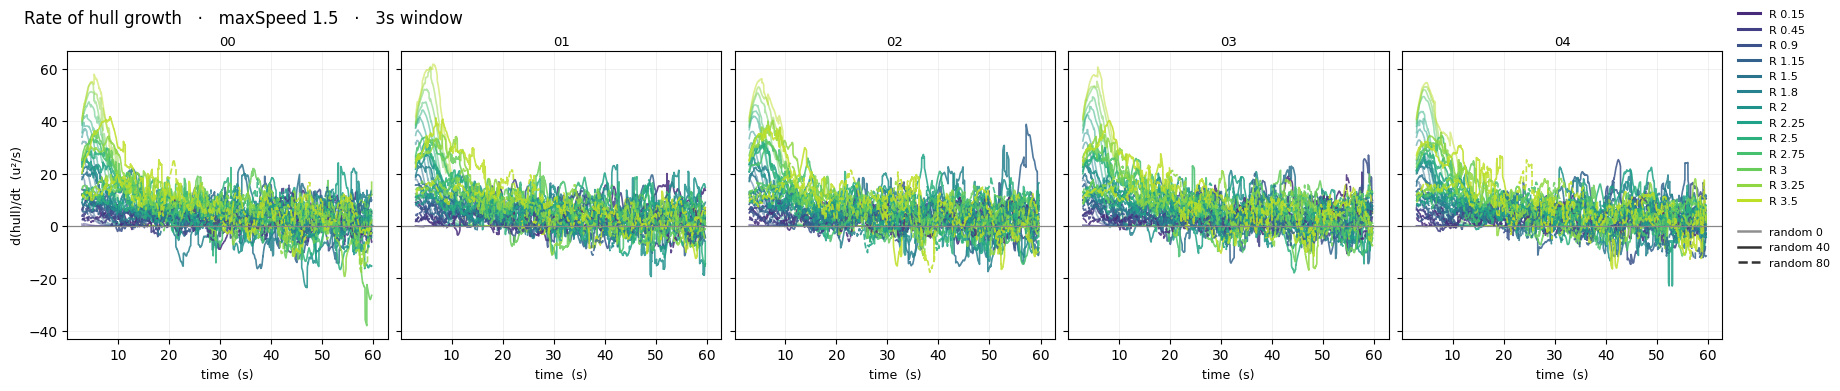

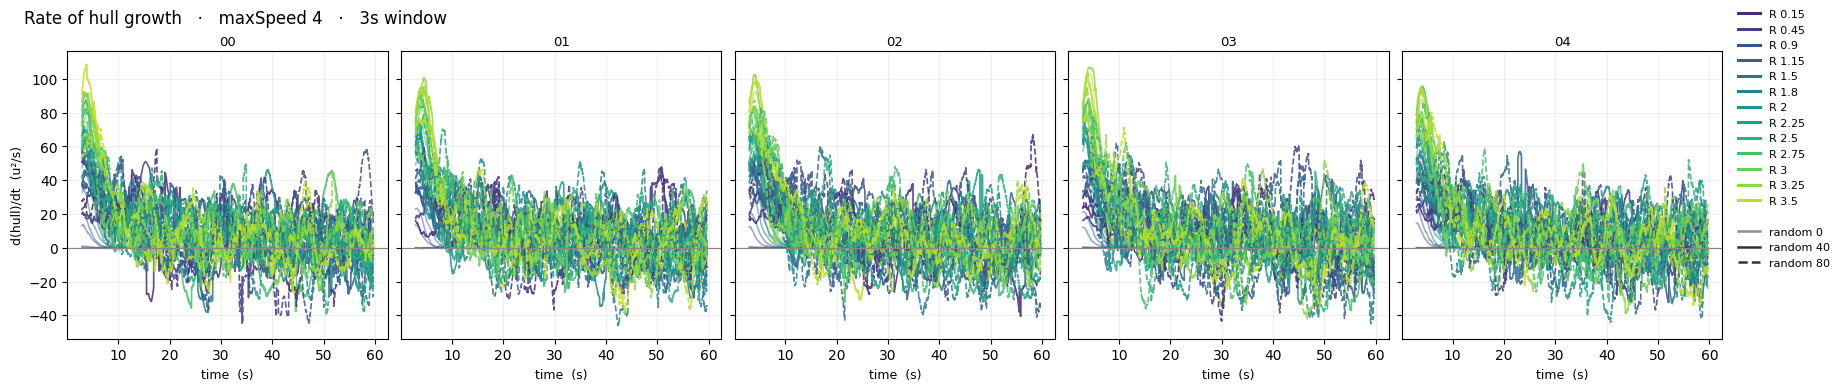

In [ ]:
for speed in inv["speeds"]:
    sst.rate_figure(runs, speed)
    plt.show()

Zooming to a few radii on one layout makes the contrast explicit.

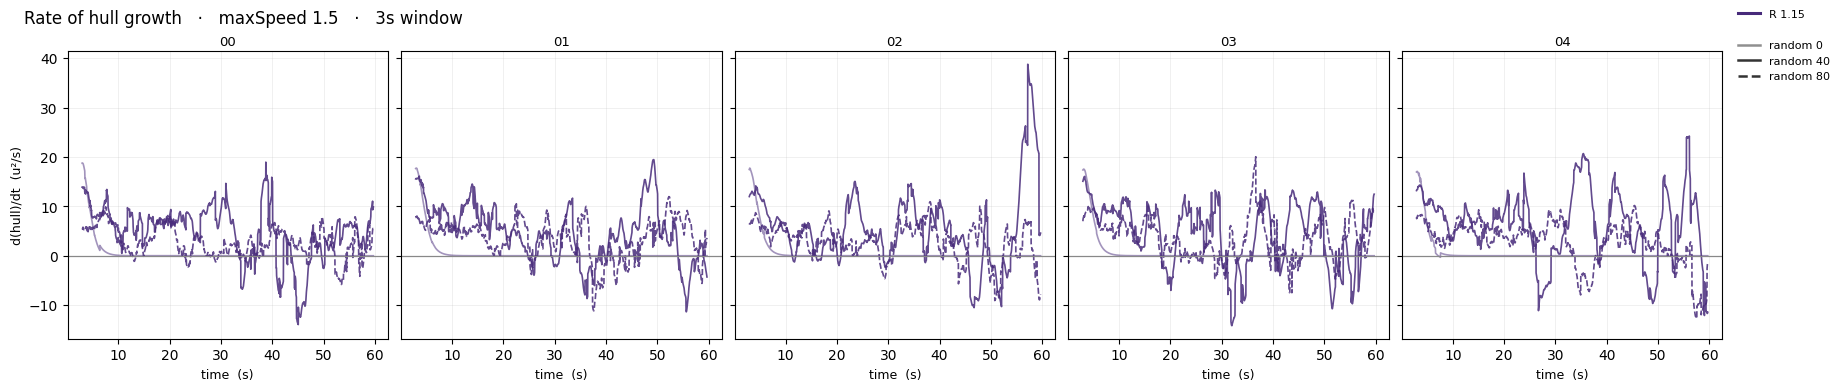

R 1.15  random 0    peak d(hull)/dt   18.8 u²/s   mean over last 20%   0.00 u²/s   back at zero -> settled
R 1.15  random 40   peak d(hull)/dt   19.0 u²/s   mean over last 20%   3.99 u²/s   still growing
R 1.15  random 80   peak d(hull)/dt    9.9 u²/s   mean over last 20%   1.41 u²/s   still growing


In [ ]:
speed = inv["speeds"][0]
few = [R for R in inv["radii"] if R == 1.15]
sst.rate_figure(runs, speed, radii=few)
plt.show()

for run in sorted(sst.select(runs, speed=speed, R=few, layout=inv["layouts"][0]),
                  key=lambda r: (r["R"], r["random"])):
    t, slope = sst._smooth_derivative(run["times"], run["areas"], 3.0)
    tail = slope[int(len(slope) * 0.8):]
    print(f"R {run['R']:<5g} random {run['random']:<3d}  "
          f"peak d(hull)/dt {slope.max():6.1f} u²/s   "
          f"mean over last 20% {tail.mean():6.2f} u²/s   "
          f"{'back at zero -> settled' if abs(tail.mean()) < 1 else 'still growing'}")

## 6. Against the no-randomness partner

The point of the shared starts. Each randomised run is divided by the reference that began from
the **same layout at the same radius**, so the ratio is a within-layout measure with the spawn
divided out. A value of 1 means randomness bought no extra dispersion.

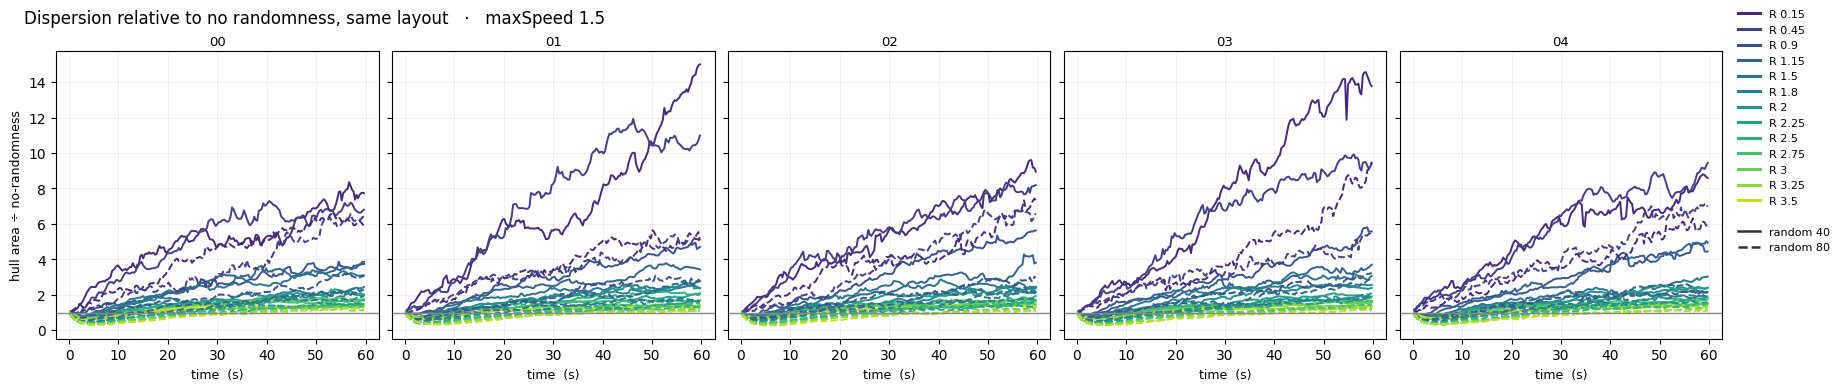

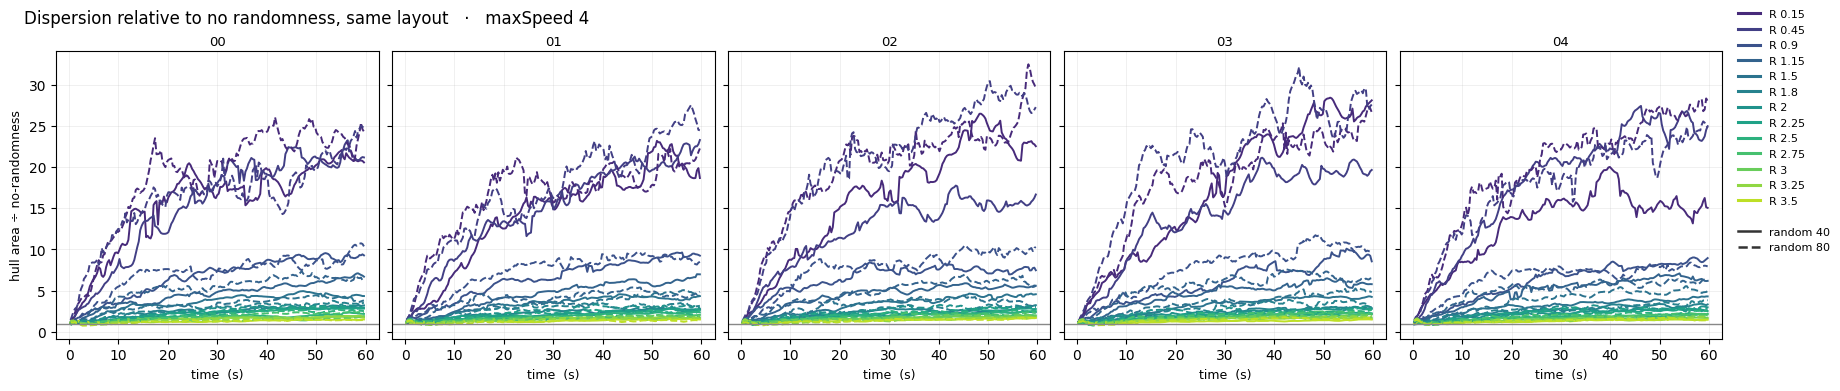

In [ ]:
for speed in inv["speeds"]:
    sst.reference_figure(runs, speed, mode="ratio")
    plt.show()

Both traces drawn together, rather than as a ratio, for the case where the absolute areas matter.
The thick pale line in each colour is the reference.

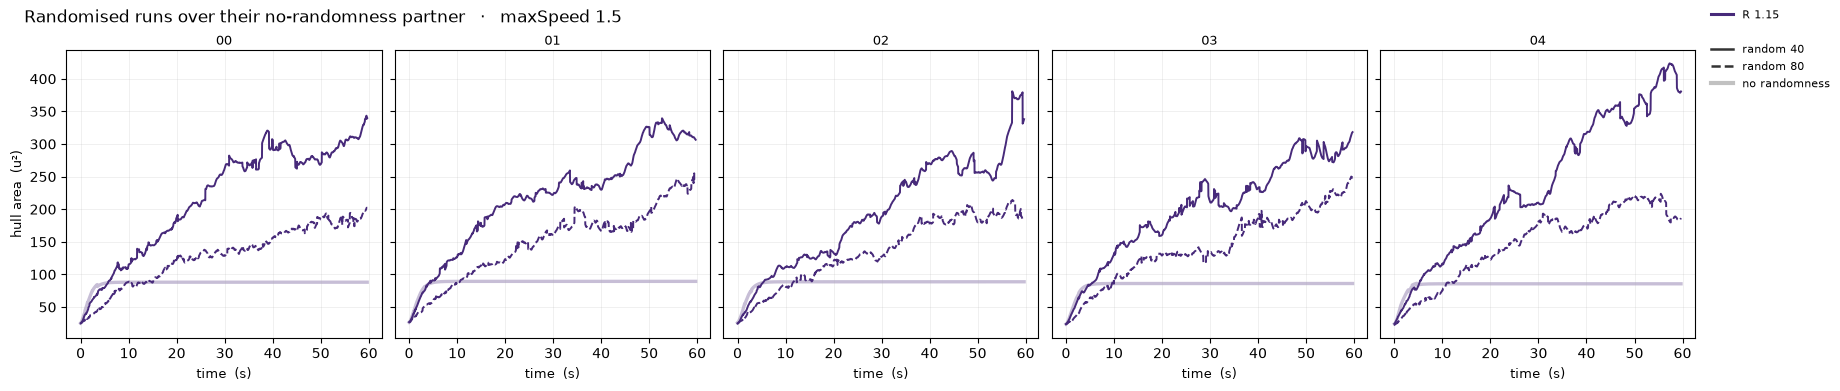

In [42]:
sst.reference_figure(runs, inv["speeds"][0], mode="overlay",
                     radii=[R for R in (0.4, 1.15, 1.9) if R in inv["radii"]])
plt.show()

## 6b. How A\*(R) is actually measured

Worth being precise about, because two things are easy to misread.

**A\* uses only the random = 0 runs.** The randomised runs never contribute to it; they are only
ever measured against it.

**A\*(R) is the mean of five plateau values, not the plateau of a mean.** Each reference run is
plateau-detected on its own and contributes one number, and the spread quoted is the spread
*across spawn layouts* — which is what makes it a paired design.

The plateau itself is not "the biggest area" or "the last frame". It is the first moment the
**rate of change** stays near zero for a sustained stretch:

1. take d(hull)/dt over a rolling 1 s window
2. require `|slope| <= 2%` of that run's own peak area, per second
3. require that to hold for 3 continuous seconds
4. report the **median** area from that point on, so one noisy frame cannot set the value

Step 2 is scaled to each run so a single setting works whether a swarm settles at 25 u² or 900 u².
Step 4 is why the plateau is robust where "final frame" would not be.

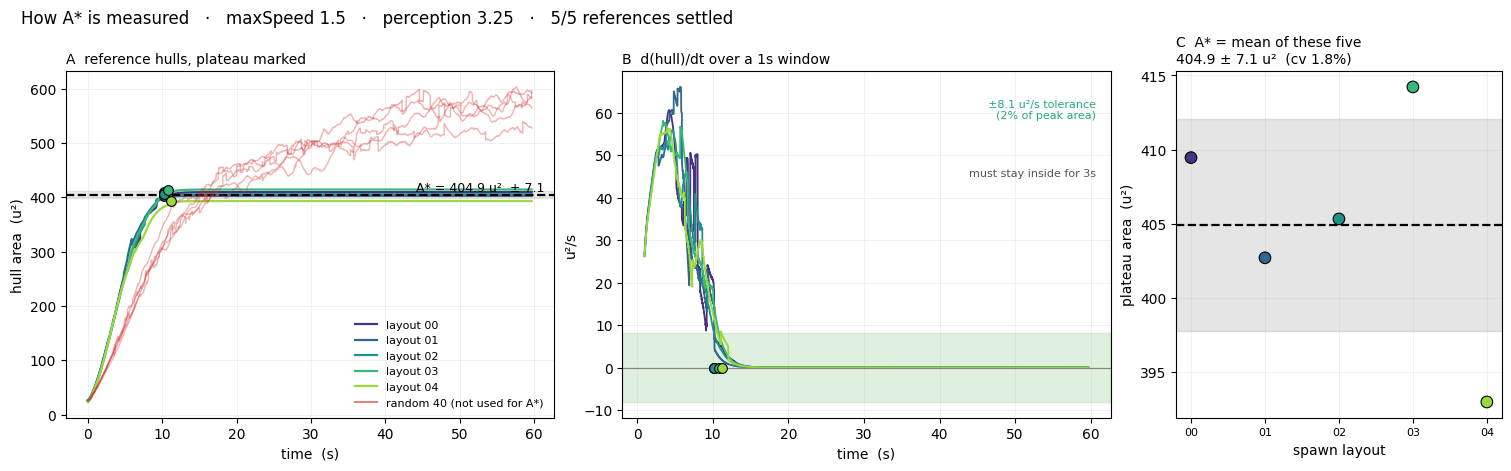

,layout,plateau_time_s,plateau_area,peak_area,last_frame_area,settled
0,00,10.20,409.46,409.46,409.46,True
1,01,10.23,402.71,402.71,402.71,True
2,02,10.18,405.33,405.33,405.33,True
3,03,10.82,414.22,414.22,414.22,True
4,04,11.23,393.00,393.00,393.00,True


A*(3.25) = mean of the five plateau areas = 404.9 u²  (sd 7.1)


In [ ]:
fig = sst.plateau_figure(runs, speed=inv["speeds"][0], radius=3.25, random_overlay=40)
plt.show()

refs = sorted(sst.select(runs, speed=inv["speeds"][0], random=0, R=3.25), key=lambda r: r["layout"])
detail = pd.DataFrame([
    {"layout": sst._short(r["layout"]),
     **{k: round(v, 2) for k, v in
        [("plateau_time_s", p["time"]), ("plateau_area", p["area"]),
         ("peak_area", float(r["areas"].max())), ("last_frame_area", float(r["areas"][-1]))]},
     "settled": p["reached"]}
    for r, p in ((r, ss.find_plateau(r["times"], r["areas"])) for r in refs)])

display(detail)
print(f"A*(3.25) = mean of the five plateau areas = {detail['plateau_area'].mean():.1f} u²  "
      f"(sd {detail['plateau_area'].std(ddof=0):.1f})")

### Where it stops working

At a radius small enough that the reference never disperses, the slope starts inside the tolerance
band and never leaves it, so the detector "finds" a plateau within a couple of seconds on a swarm
that never moved. A\* is then just the spawn area, and the randomised runs blow past it instantly.

`matched_start.py` guards against this with `MIN_SEPARATION`: a plateau within 1.2x of the spawn
area, in either direction, is reported as **UNUSABLE — reference barely moved**. Two-sided, so a
contracting Densification reference still passes.

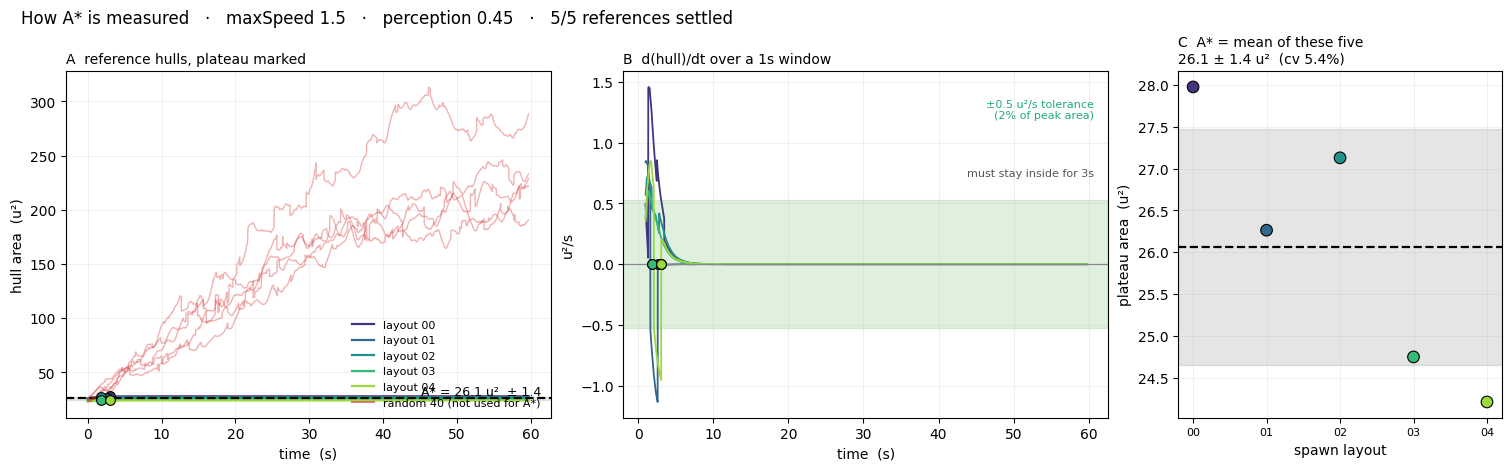

R 0.15  A*    24.9   spawn  24.9   growth  1.00x   random-40 peak  281.3   UNUSABLE
R 0.45  A*    26.1   spawn  25.0   growth  1.04x   random-40 peak  244.0   UNUSABLE
R 0.9   A*    65.8   spawn  25.0   growth  2.63x   random-40 peak  334.1   ok
R 1.15  A*    87.6   spawn  25.2   growth  3.48x   random-40 peak  361.1   ok


In [ ]:
small = min(R for R in inv["radii"] if R > inv["radii"][0])
sst.plateau_figure(runs, speed=inv["speeds"][0], radius=small, random_overlay=40)
plt.show()

for R in inv["radii"][:4]:
    refs = sst.select(runs, speed=inv["speeds"][0], random=0, R=R)
    rnd = sst.select(runs, speed=inv["speeds"][0], random=40, R=R)
    astar = np.mean([ss.find_plateau(r["times"], r["areas"])["area"] for r in refs])
    start = np.mean([r["areas"][0] for r in refs])
    peak_rnd = np.mean([r["areas"].max() for r in rnd]) if rnd else float("nan")
    verdict = "UNUSABLE" if 1/1.2 < astar/start < 1.2 else "ok"
    print(f"R {R:<5g} A* {astar:7.1f}   spawn {start:5.1f}   growth {astar/start:5.2f}x   "
          f"random-40 peak {peak_rnd:6.1f}   {verdict}")

## 7. Summary

Panel A is the peak hull area each condition reached; panel B is that peak divided by its own
no-randomness partner.

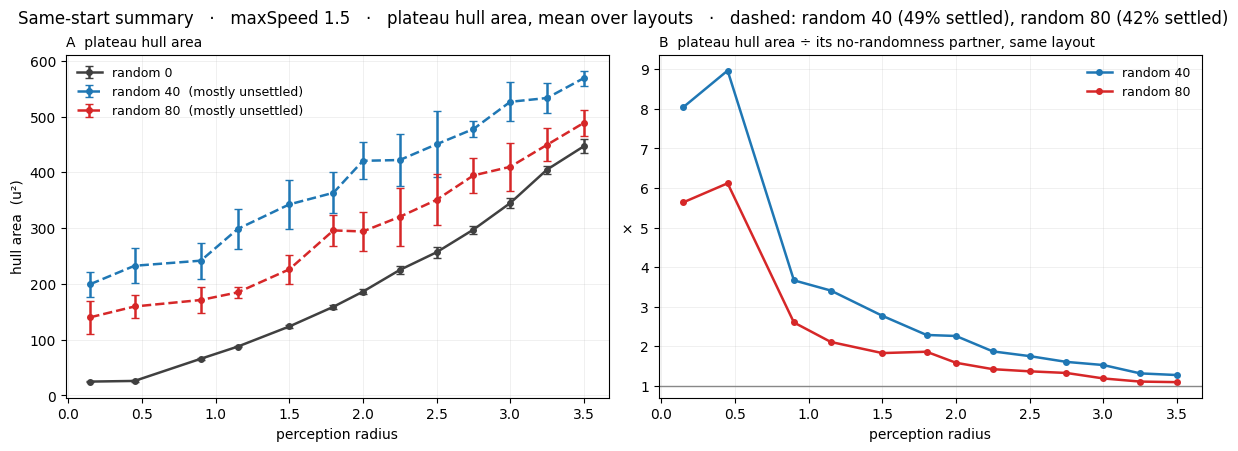

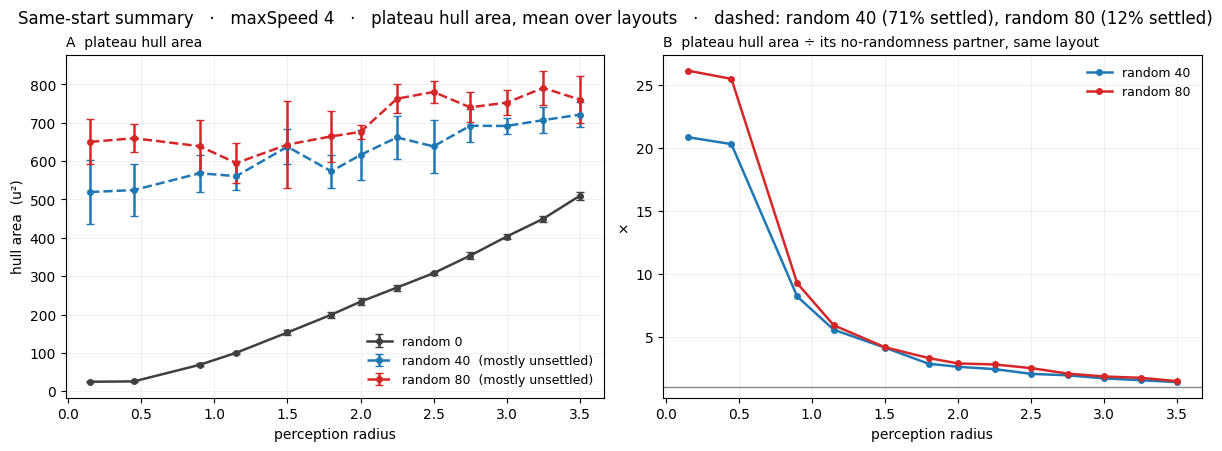

In [ ]:
for speed in inv["speeds"]:
    sst.summary_figure(runs, speed)
    plt.show()

In [ ]:
rows = []
for run in runs:
    ref = sst.select(runs, speed=run["speed"], R=run["R"], layout=run["layout"], random=0)
    rows.append({
        "maxSpeed": run["speed"], "random": run["random"], "R": run["R"],
        "peak_hull": run["areas"].max(),
        "vs_reference": run["areas"].max() / ref[0]["areas"].max() if ref else np.nan,
    })

summary = (pd.DataFrame(rows).groupby(["maxSpeed", "random", "R"])
             .mean().round(2).reset_index())
pivot = summary.pivot_table(index=["maxSpeed", "R"], columns="random", values="peak_hull")
show(pivot, "peak hull area (u²), mean over the five layouts", cmap="viridis")

peak hull area (u²), mean over the five layouts


random             0       40      80
maxSpeed R                           
1.5      0.15   24.91  281.31  177.71
         0.45   26.44  243.96  166.08
         0.90   65.85  334.10  195.61
         1.15   87.73  361.12  229.08
         1.50  123.94  374.13  259.81
         1.80  159.32  405.46  303.52
         2.00  186.42  455.42  313.11
         2.25  224.96  501.88  365.18
         2.50  256.71  489.60  387.17
         2.75  297.35  514.60  427.70
         3.00  344.93  565.82  456.12
         3.25  404.94  586.74  483.83
         3.50  446.79  617.72  517.21
4.0      0.15   24.91  600.85  681.92
         0.45   26.47  584.53  730.39
         0.90   69.10  647.76  705.17
         1.15  100.58  678.15  681.32
         1.50  153.75  698.56  760.91
         1.80  199.65  633.35  739.12
         2.00  233.56  682.95  763.26
         2.25  270.50  737.43  804.33
         2.50  308.32  723.61  810.13
         2.75  353.88  773.15  815.28
         3.00  403.36  743.46  806.58
         3.25  451.20  798.16  830.69
         3.50  509.53  791.94  839.24

### What the numbers say

Read the `random 80 / random 40` column below before drawing the obvious conclusion about
randomness.

In [ ]:
ratio = pivot.copy()
if 40 in ratio.columns and 80 in ratio.columns:
    ratio["80 / 40"] = (ratio[80] / ratio[40]).round(2)
    show(ratio.dropna(subset=["80 / 40"]), "below 1 means the noisier swarm dispersed LESS",
         cmap="coolwarm_r", subset=["80 / 40"], vmin=0.4, vmax=1.6)

    low = ratio.dropna(subset=["80 / 40"]).loc[1.5, "80 / 40"] if 1.5 in \
        ratio.dropna(subset=["80 / 40"]).index.get_level_values(0) else None
    if low is not None:
        print(f"maxSpeed 1.5: random 80 reaches {low.min():.0%} to {low.max():.0%} of "
              f"random 40's dispersion, at every radius tested.")

below 1 means the noisier swarm dispersed LESS


random              0      40      80  80 / 40
maxSpeed R                                    
1.5      0.15   24.91  281.31  177.71     0.63
         0.45   26.44  243.96  166.08     0.68
         0.90   65.85  334.10  195.61     0.59
         1.15   87.73  361.12  229.08     0.63
         1.50  123.94  374.13  259.81     0.69
         1.80  159.32  405.46  303.52     0.75
         2.00  186.42  455.42  313.11     0.69
         2.25  224.96  501.88  365.18     0.73
         2.50  256.71  489.60  387.17     0.79
         2.75  297.35  514.60  427.70     0.83
         3.00  344.93  565.82  456.12     0.81
         3.25  404.94  586.74  483.83     0.82
         3.50  446.79  617.72  517.21     0.84
4.0      0.15   24.91  600.85  681.92     1.13
         0.45   26.47  584.53  730.39     1.25
         0.90   69.10  647.76  705.17     1.09
         1.15  100.58  678.15  681.32     1.00
         1.50  153.75  698.56  760.91     1.09
         1.80  199.65  633.35  739.12     1.17
         2.00  233.56  682.95  763.26     1.12
         2.25  270.50  737.43  804.33     1.09
         2.50  308.32  723.61  810.13     1.12
         2.75  353.88  773.15  815.28     1.05
         3.00  403.36  743.46  806.58     1.08
         3.25  451.20  798.16  830.69     1.04
         3.50  509.53  791.94  839.24     1.06

maxSpeed 1.5: random 80 reaches 59% to 84% of random 40's dispersion, at every radius tested.


## 9. Defects found in this analysis code, and what they did

Every one of these was found by testing an assumption against the recordings rather than by
reading the code. They are written up because each produced a *plausible-looking* wrong answer
rather than an error, which is the kind worth remembering.

| # | Defect | What it looked like | Fix |
|---|---|---|---|
| 1 | `crossing_time` inferred the test direction from each run's own frame 0 | 8 runs reported "never reaches its reference" while expanding tenfold | direction now comes from the reference, via `Entry.Growing` |
| 2 | `MIN_GROWTH` was one-sided | a contracting Densification reference (0.03x) was rejected as "no dispersion" | two-sided `MIN_SEPARATION` |
| 3 | `discover_batches` averaged `randomMovement` and `maxSpeed` over a folder | a folder of random {0,40,80} became "random 40, maxSpeed 2.8" — a condition that never ran, silently dropped from the crossing table | conditions read per run and grouped, folders split |
| 4 | Exact/2-dp matching of `maxSpeed` | 40 of 160 runs found no reference, because the slider recorded 3.9654903 / 3.9889901 / 3.9918423 for "4" | tolerance matching, radius weighted 1000x over speed |
| 5 | `load_layouts` searched only 1 level up, and its fallback read `run["frames"]` which `load_runs` never stores | the spawn-layout figure silently did not render | walks up 4 levels; fallback reads frame 0 from disk |
| 6 | `summary_figure` plotted `areas.max()` under the label "peak", beside a reference line that is effectively the plateau | one chart, two statistics, no label | one statistic for all lines, unsettled conditions dashed |
| 7 | `load_folder` used subfolders *or* the parent, never both | running the script twice broke it: the first run creates `figures/`, the second then ignored every recording beside it | the parent is always searched |

Numbers 6 and 7 are demonstrated below, since they are the two that survived longest.

In [ ]:
# Defect 6: the two statistics are not interchangeable where it matters.
rows = []
for R in (inv["radii"][len(inv["radii"]) // 2], inv["radii"][-2]):
    for rnd in inv["randoms"]:
        sel = sst.select(runs, speed=inv["speeds"][0], random=rnd, R=R)
        if not sel:
            continue
        pl = [sst.run_statistic(r, "plateau") for r in sel]
        pk = [sst.run_statistic(r, "peak") for r in sel]
        rows.append({"R": R, "random": rnd,
                     "plateau": round(np.mean([v for v, _ in pl]), 1),
                     "peak": round(np.mean([v for v, _ in pk]), 1),
                     "peak/plateau": round(np.mean([v for v, _ in pk]) /
                                           np.mean([v for v, _ in pl]), 3),
                     "settled": f"{np.mean([s for _, s in pl]):.0%}"})

display(pd.DataFrame(rows))
print("On a settled reference the two agree (1.00x) — which is exactly why the mislabelling "
      "survived.\nOn a randomised run they differ by 8-10%.")

,R,random,plateau,peak,peak/plateau,settled
0,2.00,0,186.1,186.4,1.002,100%
1,2.00,40,420.6,455.4,1.083,20%
2,2.00,80,294.0,313.1,1.065,20%
3,3.25,0,404.9,404.9,1.000,100%
4,3.25,40,533.2,586.7,1.100,100%
5,3.25,80,449.3,483.8,1.077,80%


On a settled reference the two agree (1.00x) — which is exactly why the mislabelling survived.
On a randomised run they differ by 8-10%.


In [ ]:
# Defect 7: a subfolder appearing next to the recordings used to hide all of them.
import shutil, tempfile

probe = Path(tempfile.mkdtemp())
for f in sorted(RECORDINGS.glob("*.json"))[:12]:
    shutil.copy(f, probe / f.name)

clean = len(sst.load_folder(probe))
(probe / "figures").mkdir()
(probe / "figures" / "leftover.png").write_bytes(b"")
after = len(sst.load_folder(probe))

print(f"recordings found in a clean folder      : {clean}")
print(f"recordings found once figures/ exists   : {after}")
print("same number -> fixed" if clean == after else "MISMATCH -> still broken")
shutil.rmtree(probe)

recordings found in a clean folder      : 11
recordings found once figures/ exists   : 11
same number -> fixed


### What none of these were

None was a fault in the swarm model, the hull algorithm, or the recorder. `validate_hull.py` still
checks the recorded areas against `scipy.spatial.ConvexHull` independently, and the Unity plateau
port was verified bit-identical to `steady_state.find_plateau` across 160 reference recordings.

Every defect above was in the *analysis layer* — how runs were grouped, matched, or summarised. That
is the layer with no ground truth to check against, which is why each one had to be caught by
constructing a case where the right answer was known in advance.

## Caveats

- **The randomised conditions mostly do not converge.** Their hulls are still climbing at the 60 s
  timeout, which is visible in section 5 as a slope that never returns to zero. Any "final" number
  for those runs is where the clip stopped, not where the swarm settled.
- **Coverage is asymmetric.** At maxSpeed 1.5 the randomised runs cover R 0.15–1.90 only; at
  maxSpeed 4 they cover R 2.15–3.90 only. There is no radius at which the two speeds can be
  compared under randomness.
- **The large radii are arena-limited.** Above R ≈ 2.4 even the reference has agents on the walls
  by its plateau, so hull area there is partly a measurement of the box.
- **Frame 0 is not exactly the spawn** for randomised runs, by roughly one agent diameter. Section 2
  quantifies it. Fixing it properly means starting trajectory capture before motion is enabled.